# Sparse Jacobians and Hessians with `asdex`

POUNCE's sparse interface wants two things for each matrix: a *structure*
— the `(rows, cols)` index pair naming which entries can ever be nonzero —
and a *values* callback returning those entries in that order. Deriving the
structure by hand is the tedious, error-prone part of setting up a large NLP,
and getting it wrong is not a crash but a wrong answer.

[`asdex`](https://github.com/adrhill/asdex) removes that step for JAX
models. It walks the jaxpr with abstract interpretation to recover a global
sparsity pattern, then colors it so the whole matrix falls out of a handful
of AD passes instead of one per variable. This notebook wires it to POUNCE
two ways, measures what the coloring buys, and shows the case that motivates
using a *proved* pattern rather than a sampled one.

`pip install asdex` alongside `pounce-solver[jax]`.

In [1]:
import time

import asdex
import jax
import jax.numpy as jnp
import numpy as np

import pounce
from pounce.jax import from_jax

jax.config.update("jax_enable_x64", True)

## 1. A problem with real structure

`clnlbeam` is a standard nonconvex optimal-control benchmark: an elastic
beam discretized on $N+1$ nodes, with angle $t$, deflection $x$, and control
$u$ stacked into one vector $z = (t, x, u)$. The dynamics enter as $2N$
equality constraints, each touching only neighbouring nodes.

We add a control-smoothing term $\tfrac{\beta h}{2}\sum_i (u_{i+1}-u_i)^2$,
which is standard in optimal control and is what couples adjacent $u$'s. With
$\beta = 0$ the Lagrangian Hessian is exactly diagonal; with $\beta > 0$ it is
tridiagonal. The coloring below responds to that difference, which is a good
way to see it is reading real structure rather than guessing.

In [2]:
N = 200
h = 1.0 / N
alpha = 350.0   # bending stiffness
beta = 1.0      # control smoothing


def objective(z):
    t, _x, u = jnp.split(z, 3)
    effort = jnp.sum(0.5 * h * (u[1:] ** 2 + u[:-1] ** 2))
    bending = jnp.sum(0.5 * alpha * h * (jnp.cos(t[1:]) + jnp.cos(t[:-1])))
    smoothing = 0.5 * beta * h * jnp.sum((u[1:] - u[:-1]) ** 2)
    return effort + bending + smoothing


def constraints(z):
    t, x, u = jnp.split(z, 3)
    return jnp.concatenate([
        x[1:] - x[:-1] - 0.5 * h * (jnp.sin(t[1:]) + jnp.sin(t[:-1])),
        t[1:] - t[:-1] - 0.5 * h * (u[1:] + u[:-1]),
    ])


def lagrangian(z, lam, sigma):
    return sigma * objective(z) + jnp.dot(lam, constraints(z))


n = 3 * (N + 1)
z0 = jnp.zeros(n)
m = int(constraints(z0).shape[0])
print(f"n = {n} variables, m = {m} equality constraints")

n = 603 variables, m = 400 equality constraints


## 2. Detecting the pattern

`jacobian_sparsity` and `hessian_sparsity` return a `SparsityPattern` with
`.rows` / `.cols` — already the `(rows, cols)` pair POUNCE's structure
callbacks expect. Nothing here evaluates the model at a sample point in the
statistical sense: the pattern is derived from the computation graph and is
valid for *every* input.

The Hessian POUNCE needs is the Hessian of the Lagrangian
$\nabla^2(\sigma f + \lambda^\top g)$, so we detect on `lagrangian`, treating
$z$ as the differentiated argument.

In [3]:
jac_pat = asdex.jacobian_sparsity(constraints, z0)
hess_pat = asdex.hessian_sparsity(lagrangian, z0, jnp.ones(m), 1.0)

for name, p in (("constraint Jacobian", jac_pat), ("Lagrangian Hessian", hess_pat)):
    print(f"{name:22s} {str(p.shape):14s} nnz = {p.nnz:6d}  "
          f"density = {p.density:.2e}")

constraint Jacobian    (400, 603)     nnz =   1600  density = 6.63e-03
Lagrangian Hessian     (603, 603)     nnz =    802  density = 2.21e-03


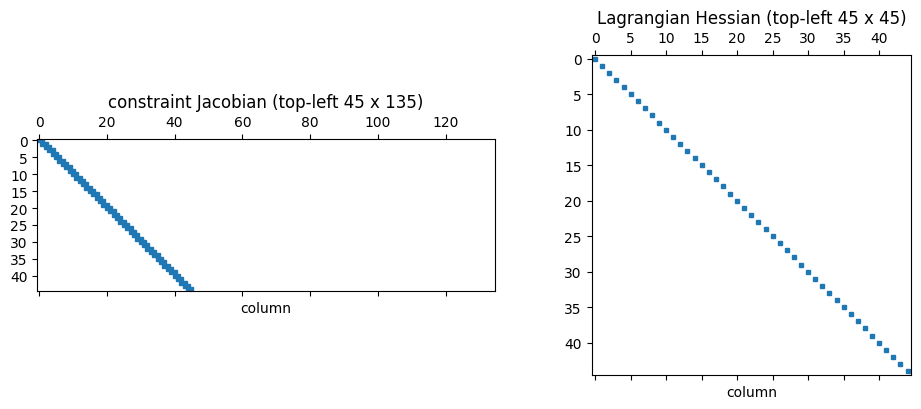

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
k = 45   # a corner, so the band is actually visible at this scale
axes[0].spy(np.asarray(jac_pat.todense())[:k, : 3 * k], markersize=3)
axes[0].set_title(f"constraint Jacobian (top-left {k} x {3 * k})")
axes[1].spy(np.asarray(hess_pat.todense())[:k, :k], markersize=3)
axes[1].set_title(f"Lagrangian Hessian (top-left {k} x {k})")
for ax in axes:
    ax.set_xlabel("column")
fig.tight_layout()
plt.show()

## 3. Coloring: how many AD passes

A pattern alone still leaves you evaluating one AD pass per variable. Coloring
groups columns that share no row, so each group can be recovered in a single
pass and unpacked afterwards. `num_colors` is the number of AD passes the
matrix actually costs.

The Hessian uses a symmetric (star) coloring and `fwd_over_rev`; the Jacobian
picks forward or reverse mode based on its shape.

In [5]:
jac_col = asdex.jacobian_coloring(constraints, z0)
hess_col = asdex.hessian_coloring(lagrangian, z0, jnp.ones(m), 1.0)

for name, c in (("Jacobian", jac_col), ("Hessian", hess_col)):
    print(f"{name:10s} {c.num_colors:3d} colors  (mode={c.mode})  "
          f"vs {n} passes for a dense build  "
          f"-> {n / c.num_colors:.0f}x fewer")

Jacobian     4 colors  (mode=fwd)  vs 603 passes for a dense build  -> 151x fewer
Hessian      3 colors  (mode=fwd_over_rev)  vs 603 passes for a dense build  -> 201x fewer


## 4. Handing the pattern to POUNCE

`pounce.jax.from_jax` already speaks this language: `jac_pattern` and
`hess_pattern` take the same `(rows, cols)` form, and `sparse=True` switches
the per-evaluation cost to one JVP/HVP per color. Supplying asdex's pattern
short-circuits POUNCE's own detection entirely.

`hess_pattern` wants the lower triangle, but upper-triangle entries are
folded onto their mirror, so asdex's full symmetric pattern can go straight
in.

Three configurations, same problem — dense, POUNCE's built-in probe, and
asdex's pattern:

In [6]:
grid = jnp.arange(N + 1) * h
start = np.asarray(jnp.concatenate([
    0.05 * jnp.cos(grid), 0.05 * jnp.cos(grid), jnp.zeros(N + 1)]))
lb = np.concatenate([np.full(N + 1, -1.0), np.full(N + 1, -0.05),
                     np.full(N + 1, -np.inf)])
ub = np.concatenate([np.full(N + 1, 1.0), np.full(N + 1, 0.05),
                     np.full(N + 1, np.inf)])
cl = cu = np.zeros(m)

jp = (np.asarray(jac_pat.rows), np.asarray(jac_pat.cols))
hp = (np.asarray(hess_pat.rows), np.asarray(hess_pat.cols))

shared = dict(n=n, m=m, lb=lb, ub=ub, cl=cl, cu=cu)
results = {}
for label, extra in (
    ("dense", dict(sparse=False)),
    ("sparse + probe", dict(sparse=True)),
    ("sparse + asdex", dict(sparse=True, jac_pattern=jp, hess_pattern=hp)),
):
    t0 = time.perf_counter()
    prob = from_jax(objective, constraints, **shared, **extra)
    t_build = time.perf_counter() - t0
    prob.add_option("print_level", 0)
    t0 = time.perf_counter()
    xs, info = prob.solve(start.copy())
    t_solve = time.perf_counter() - t0
    results[label] = xs
    print(f"{label:16s} build {t_build:5.2f}s  solve {t_solve:6.3f}s  "
          f"iters {info['iter_count']:3d}  f = {info['obj_val']:.9f}")

ref = np.asarray(results["dense"])
for label, xs in results.items():
    print(f"  {label:16s} max|x - x_dense| = "
          f"{np.abs(np.asarray(xs) - ref).max():.2e}")

dense            build  0.09s  solve  0.181s  iters  37  f = 329.913793375
sparse + probe   build  0.08s  solve  0.106s  iters  37  f = 329.913793375


sparse + asdex   build  0.01s  solve  0.102s  iters  37  f = 329.913793375
  dense            max|x - x_dense| = 0.00e+00
  sparse + probe   max|x - x_dense| = 1.59e-14
  sparse + asdex   max|x - x_dense| = 1.59e-14


All three land on the same solution. At this size the build cost is where
asdex shows up — the pattern comes out of one graph walk instead of repeated
blocked AD sweeps over the whole matrix.

## 5. What the coloring is worth as $n$ grows

The point of a colored pattern is that its cost tracks the *bandwidth*, not
the dimension. Here the color counts should stay pinned while $n$ grows,
because refining the discretization adds nodes without widening the stencil.

In [7]:
def build(N):
    h = 1.0 / N

    def obj(z):
        t, _x, u = jnp.split(z, 3)
        return (jnp.sum(0.5 * h * (u[1:] ** 2 + u[:-1] ** 2))
                + jnp.sum(0.5 * alpha * h * (jnp.cos(t[1:]) + jnp.cos(t[:-1])))
                + 0.5 * beta * h * jnp.sum((u[1:] - u[:-1]) ** 2))

    def con(z):
        t, x, u = jnp.split(z, 3)
        return jnp.concatenate([
            x[1:] - x[:-1] - 0.5 * h * (jnp.sin(t[1:]) + jnp.sin(t[:-1])),
            t[1:] - t[:-1] - 0.5 * h * (u[1:] + u[:-1]),
        ])

    return obj, con, lambda z, l, s: s * obj(z) + jnp.dot(l, con(z))


def timeit(fn, *a, reps=5):
    jax.block_until_ready(fn(*a))
    t0 = time.perf_counter()
    for _ in range(reps):
        jax.block_until_ready(fn(*a))
    return (time.perf_counter() - t0) / reps


print(f"{'N':>6}{'n':>7}{'J colors':>10}{'H colors':>10}"
      f"{'sparse H':>11}{'dense H':>11}{'speedup':>10}{'dense MB':>10}")
for Nk in (50, 100, 200, 400, 800, 1600):
    obj_k, con_k, lag_k = build(Nk)
    nk = 3 * (Nk + 1)
    zk = jnp.zeros(nk)
    mk = int(con_k(zk).shape[0])
    lk = jnp.ones(mk)

    jc = asdex.jacobian_coloring(con_k, zk)
    hc = asdex.hessian_coloring(lag_k, zk, lk, 1.0)
    t_sparse = timeit(jax.jit(asdex.hessian_from_coloring(lag_k, hc)), zk, lk, 1.0)
    t_dense = timeit(jax.jit(jax.hessian(lag_k)), zk, lk, 1.0)

    print(f"{Nk:6d}{nk:7d}{jc.num_colors:10d}{hc.num_colors:10d}"
          f"{t_sparse * 1e3:10.2f}ms{t_dense * 1e3:10.2f}ms"
          f"{t_dense / t_sparse:9.0f}x{nk * nk * 8 / 1e6:10.1f}")

     N      n  J colors  H colors   sparse H    dense H   speedup  dense MB


    50    153         4         3      0.04ms      0.04ms        1x       0.2


   100    303         4         3      0.01ms      0.10ms        7x       0.7
   200    603         4         3      0.02ms      0.22ms       12x       2.9


   400   1203         4         3      0.02ms      0.71ms       32x      11.6


   800   2403         4         3      0.03ms      5.30ms      157x      46.2


  1600   4803         4         3      0.04ms     29.06ms      656x     184.6


The color counts do not move. The sparse Hessian stays flat in wall-clock
while the dense one grows quadratically in both time and memory — by
$N = 1600$ the dense Hessian is a 185 MB array that takes roughly 650x
longer to form, and it is still 99.8% zeros. Note the $N = 50$ row: at
that size the coloring buys nothing, which is the honest lower end of
the range.

## 6. Why a *proved* pattern beats a sampled one

POUNCE detects sparsity by probing: it evaluates derivatives at a few random
points and unions the nonzeros. That is fast and right for structure fixed by
the expression graph, and `from_jax`'s own docstring is explicit about where
it stops — a supplied pattern is *"the only safe one for genuinely
value-dependent sparsity, which no probe can detect reliably."*

Here is that case. The coupling between $x_1$ and $x_2$ only switches on when
$x_0 > 0$, so a probe drawn in the other half of the domain sees a separable
function:

In [8]:
def gated(x):
    return jnp.sum(x ** 2) + jnp.where(x[0] > 0.0, x[1] * x[2], 0.0)


ng = 4
closed = jnp.array([-1.0, 0.7, 0.3, 0.2])   # gate shut at this point
gate_pat = asdex.hessian_sparsity(gated, closed)

print("asdex, detected at a point where the gate is SHUT:")
print(np.asarray(gate_pat.todense()).astype(int))
print("finds the (1,2) coupling:", bool(np.asarray(gate_pat.todense())[1, 2]))

asdex, detected at a point where the gate is SHUT:
[[1 0 0 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 0 0 1]]
finds the (1,2) coupling: True


asdex reports the coupling even though it detected at a point where that
branch is dead — the pattern is a statement about the graph, not the point.

A probe has no way to know. Sweeping seeds, some miss it outright; and under
`sparse=True` a missed entry is worse than a dropped one, because it corrupts
the compression seed and *aliases into the entries that share its color*:

In [9]:
from pounce.jax._build import _JaxProblem

misses = [
    s for s in range(24)
    if not np.any(
        (_JaxProblem(gated, None, n=ng, m=0, sparse=True, seed=s, n_probes=3)._hess_rows == 2)
        & (_JaxProblem(gated, None, n=ng, m=0, sparse=True, seed=s, n_probes=3)._hess_cols == 1)
    )
]
print(f"seeds whose probe missed the coupling: {misses}  ({len(misses)}/24)")

open_pt = np.array([1.0, 0.7, 0.3, 0.2])    # gate live: the coupling is real
truth = np.asarray(jax.hessian(gated)(jnp.asarray(open_pt)))

for label, kw in (
    (f"probe (seed {misses[0]})", dict(sparse=True, seed=misses[0], n_probes=3)),
    ("asdex pattern", dict(sparse=True, hess_pattern=(np.asarray(gate_pat.rows),
                                                      np.asarray(gate_pat.cols)))),
):
    po = _JaxProblem(gated, None, n=ng, m=0, **kw)
    H = np.zeros((ng, ng))
    H[po._hess_rows, po._hess_cols] = np.asarray(po.hessian(open_pt, np.zeros(0), 1.0))
    H = H + np.tril(H, -1).T
    print(f"\n{label}: nnz = {len(po._hess_rows)}, "
          f"max abs error = {np.abs(H - truth).max()}")
    print(H)

print("\ntrue Hessian at that point:")
print(truth)

seeds whose probe missed the coupling: [4]  (1/24)



probe (seed 4): nnz = 4, max abs error = 1.0
[[2. 0. 0. 0.]
 [0. 3. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 2.]]

asdex pattern: nnz = 5, max abs error = 0.0
[[2. 0. 0. 0.]
 [0. 2. 1. 0.]
 [0. 1. 2. 0.]
 [0. 0. 0. 2.]]

true Hessian at that point:
[[2. 0. 0. 0.]
 [0. 2. 1. 0.]
 [0. 1. 2. 0.]
 [0. 0. 0. 2.]]


The missed entry does not come back as a zero. Its value is folded into the
diagonal — the probe-built Hessian reports $H_{11} = H_{22} = 3$ where the
truth is $2$ — so the solver is handed plausible, wrong curvature with no
error raised anywhere. asdex's pattern reproduces the Hessian exactly.

This is the argument for `asdex` over probing even when speed is not the
concern: `jnp.where`, `jnp.clip`, `jnp.maximum` and friends are ordinary in
engineering models, and every one of them is a gate of this kind.

## 7. Full control: the raw structure/values object

`from_jax` is the short path. If you need the callbacks themselves — to mix
in hand-written derivatives, or to drive `pounce.Problem` directly — the same
pattern feeds the cyipopt-style protocol. The one wrinkle is ordering: asdex
returns values in its own BCOO index order, so build the permutation onto
your declared structure once, at setup.

In [10]:
jac_fn = jax.jit(asdex.jacobian_from_coloring(constraints, jac_col))
hess_fn = jax.jit(asdex.hessian_from_coloring(lagrangian, hess_col))
f_val, f_grad = jax.jit(objective), jax.jit(jax.grad(objective))
g_val = jax.jit(constraints)

jr, jc_ = np.asarray(jac_pat.rows), np.asarray(jac_pat.cols)
hr_all, hc_all = np.asarray(hess_pat.rows), np.asarray(hess_pat.cols)
lower = hr_all >= hc_all              # POUNCE wants the lower triangle
hr, hc_ = hr_all[lower], hc_all[lower]


def order_map(bcoo_indices, rows, cols, ncols):
    """Permutation taking asdex's value order to our declared structure."""
    key_have = bcoo_indices[:, 0].astype(np.int64) * ncols + bcoo_indices[:, 1]
    key_want = rows.astype(np.int64) * ncols + cols
    order = np.argsort(key_have)
    pos = order[np.searchsorted(key_have[order], key_want)]
    assert np.array_equal(key_have[pos], key_want), "structure/value mismatch"
    return pos


jac_map = order_map(np.asarray(jac_fn(z0).indices), jr, jc_, n)
hess_map = order_map(np.asarray(hess_fn(z0, jnp.ones(m), 1.0).indices), hr, hc_, n)


class Beam:
    def objective(self, z):
        return float(f_val(z))

    def gradient(self, z):
        return np.asarray(f_grad(z))

    def constraints(self, z):
        return np.asarray(g_val(z))

    def jacobianstructure(self):
        return jr, jc_

    def jacobian(self, z):
        return np.asarray(jac_fn(z).data)[jac_map]

    def hessianstructure(self):
        return hr, hc_

    def hessian(self, z, lagrange, obj_factor):
        return np.asarray(hess_fn(z, lagrange, obj_factor).data)[hess_map]


prob = pounce.Problem(n=n, m=m, problem_obj=Beam(), lb=lb, ub=ub, cl=cl, cu=cu)
prob.add_option("print_level", 0)
z_sol, info = prob.solve(start.copy())
print(f"status {info['status']}  f = {info['obj_val']:.9f}  "
      f"iters {info['iter_count']}")
print(f"agrees with from_jax: "
      f"{np.abs(np.asarray(z_sol) - ref).max():.2e}")

status 0  f = 329.913793375  iters 37
agrees with from_jax: 9.83e-15


## When to reach for it

| Situation | What to use |
|---|---|
| Small or genuinely dense model | `from_jax(..., sparse=False)` — coloring overhead buys nothing |
| Large model, structure fixed by the expression graph | `from_jax(..., sparse=True)` — the built-in probe is fine and needs no extra dependency |
| Structure known in closed form (collocation, PDE stencils) | Write `jac_pattern` / `hess_pattern` yourself |
| Large JAX model, structure you would rather not hand-derive | `asdex` patterns into `jac_pattern` / `hess_pattern` |
| Model containing `where` / `clip` / `maximum`, i.e. value-dependent structure | `asdex` — a probe can be silently wrong here |

Practical rule: **let the probe handle straight-line algebra, and reach for
`asdex` the moment the model branches.** The cost difference between them is
modest and shows up mostly at build time; the correctness difference is not
modest, and it fails quietly.

Two things worth carrying away about the mechanics. The Hessian POUNCE wants
is the Hessian of the *Lagrangian*, so detect on
$\sigma f + \lambda^\top g$ rather than on the objective alone, or the
constraint curvature is missing from the pattern. And a pattern only has to
be a **superset** of the truth: extra entries report zeros and may cost a
color, while a missing one corrupts the result — which is exactly why a
conservative graph-derived pattern is the safe default.